In [19]:
#Machine Learning model for Ember Mobile churn prediction

In [20]:
import pandas as pd
from sqlalchemy import create_engine

In [21]:

USER = "root"       # e.g., "root"
PASSWORD = "Jk12021993!"
HOST = "localhost"          
PORT = 3306                  
DATABASE = "embermobile"

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
)

df = pd.read_sql("SELECT * FROM ember_ml", engine)

print(f"Shape: {df.shape}")
df.head(30)

Shape: (20681, 21)


,customerID,IsChurned,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,PhoneService,...,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,EMB-0010349,0,Male,0,Yes,Yes,60,110.60,6586.85,Yes,...,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check
1,EMB-0007087,0,Female,0,Yes,No,6,48.94,283.50,Yes,...,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic)
2,EMB-0009086,0,Male,0,Yes,Yes,8,73.04,581.01,Yes,...,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
3,EMB-0020906,0,Male,0,No,No,31,50.05,1523.40,No,...,DSL,No,No,Yes,No,Yes,Yes,One year,Yes,Electronic check
4,EMB-0002409,0,Female,0,No,No,5,55.80,300.40,Yes,...,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Credit card (automatic)
5,EMB-0020894,0,Female,0,No,No,41,40.35,1677.85,No,...,DSL,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check
6,EMB-0003826,0,Male,0,Yes,Yes,60,76.95,4543.95,Yes,...,DSL,No,Yes,No,Yes,Yes,Yes,Two year,No,Bank transfer (automatic)
7,EMB-0020456,0,Female,1,No,No,5,65.79,328.59,Yes,...,DSL,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Electronic check
8,EMB-0010697,0,Female,0,Yes,No,42,19.25,807.05,Yes,...,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check
9,EMB-0003382,0,Female,0,Yes,No,20,19.25,375.25,Yes,...,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic)


In [22]:
# Class balance
print("Churn rate:")
print(df['IsChurned'].value_counts(normalize=True))

# Missing values
print("\nNulls per column:")
print(df.isnull().sum())

# Column types
print("\nDtypes:")
print(df.dtypes)

Churn rate:
IsChurned
0    0.743774
1    0.256226
Name: proportion, dtype: float64

Nulls per column:
customerID          0
IsChurned           0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
MonthlyCharges      0
TotalCharges        0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
dtype: int64

Dtypes:
customerID              str
IsChurned             int64
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
MonthlyCharges      float64
TotalCharges        float64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection      

In [23]:
# Numeric summary
df.describe()

# Churn rate by contract 
df.groupby('Contract')['IsChurned'].mean().sort_values(ascending=False)

# Churn rate by payment method
df.groupby('PaymentMethod')['IsChurned'].mean().sort_values(ascending=False)

PaymentMethod
Electronic check             0.441345
                             0.238095
Mailed check                 0.183656
Bank transfer (automatic)    0.166415
Credit card (automatic)      0.146039
Name: IsChurned, dtype: float64

In [24]:

import pandas as pd
from sklearn.model_selection import train_test_split

#ensure total charges is numeric, coercing errors to NaN and filling them with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

#  Separate features (X) from label (y).
 
X = df.drop(columns=['customerID', 'IsChurned'])
y = df['IsChurned']

#  One-hot encode all text category
X = pd.get_dummies(X, drop_first=True)


print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution:\n{y.value_counts(normalize=True)}")
X.head()

Feature matrix shape: (20681, 41)
Label distribution:
IsChurned
0    0.743774
1    0.256226
Name: proportion, dtype: float64


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,gender_Male,gender_female,gender_male,Partner_Yes,...,Contract_ One year,Contract_ Two year,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,60,110.60,6586.85,False,True,False,False,False,True,...,False,False,False,False,True,True,False,False,True,False
1,0,6,48.94,283.50,False,False,False,False,False,True,...,False,False,True,False,False,True,True,False,False,False
2,0,8,73.04,581.01,False,True,False,False,False,True,...,False,False,True,False,False,True,False,False,True,False
3,0,31,50.05,1523.40,False,True,False,False,False,False,...,False,False,False,True,False,True,False,False,True,False
4,0,5,55.80,300.40,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       #20% held out for testing
    stratify=y,          # keep 26% churn rate in both sets
    random_state=42      
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate:  {y_test.mean():.3f}")

Train shape: (16544, 41)
Test shape:  (4137, 41)
Train churn rate: 0.256
Test churn rate:  0.256


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Build a pipeline: scale features → fit logistic regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Train on training set only
pipe_lr.fit(X_train, y_train)

# Score
train_acc = pipe_lr.score(X_train, y_train)
test_acc  = pipe_lr.score(X_test, y_test)
train_auc = roc_auc_score(y_train, pipe_lr.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test,  pipe_lr.predict_proba(X_test)[:, 1])

print(f"Train accuracy: {train_acc:.3f}   Train AUC: {train_auc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}   Test AUC: {test_auc:.3f}")

Train accuracy: 0.804   Train AUC: 0.844
Test accuracy:  0.810   Test AUC: 0.851


#Now going to try XG Boost. 

In [27]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,       # build 300 trees
    max_depth=5,            # each tree at most 5 levels deep
    learning_rate=0.1,      # how much each tree adjusts predictions
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1               # use all CPU cores
)

# Fit — trees don't need scaling, so no pipeline needed
model.fit(X_train, y_train)

# Score
train_acc = model.score(X_train, y_train)
test_acc  = model.score(X_test, y_test)
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test,  model.predict_proba(X_test)[:, 1])

print(f"Train accuracy: {train_acc:.3f}   Train AUC: {train_auc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}   Test AUC: {test_auc:.3f}")

Train accuracy: 0.871   Train AUC: 0.941
Test accuracy:  0.833   Test AUC: 0.892


In [28]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

y_pred = model.predict(X_test)                    # class predictions (default threshold 0.5)
y_proba = model.predict_proba(X_test)[:, 1]       # churn probabilities

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("Layout: [[TN, FP], [FN, TP]]")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

Accuracy:  0.833
Precision: 0.707
Recall:    0.597
F1:        0.648
ROC AUC:   0.892

Confusion matrix:
[[2815  262]
 [ 427  633]]
Layout: [[TN, FP], [FN, TP]]

Full classification report:
              precision    recall  f1-score   support

      Active       0.87      0.91      0.89      3077
     Churned       0.71      0.60      0.65      1060

    accuracy                           0.83      4137
   macro avg       0.79      0.76      0.77      4137
weighted avg       0.83      0.83      0.83      4137



#Now going to test a number of thresholds and see how thee XGboost model performs

In [29]:
import numpy as np
import pandas as pd

# Test a range of thresholds
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7] #from below picked 0.3 as threshold for model

results = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    results.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t),
        'recall':    recall_score(y_test, y_pred_t),
        'f1':        f1_score(y_test, y_pred_t),
        'flagged':   tp + fp,          # total customers you'd contact
        'caught':    tp,               # real churners you'd save
        'missed':    fn,               # real churners you'd miss
        'false_alarms': fp,            # wasted outreach
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 threshold  precision   recall       f1  flagged  caught  missed  false_alarms
       0.2   0.521904 0.910377 0.663458     1849     965      95           884
       0.3   0.589178 0.832075 0.689871     1497     882     178           615
       0.4   0.646372 0.731132 0.686144     1199     775     285           424
       0.5   0.707263 0.597170 0.647570      895     633     427           262
       0.6   0.777778 0.462264 0.579882      630     490     570           140
       0.7   0.844875 0.287736 0.429275      361     305     755            56


In [ ]:
import shap

# Create the explainer TreeExplainer is optimized for XGBoost/LightGBM/RF
explainer = shap.TreeExplainer(model)


shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")  # (4137, 41)

SHAP values shape: (4137, 41)


In [ ]:
#SHAP summary plot

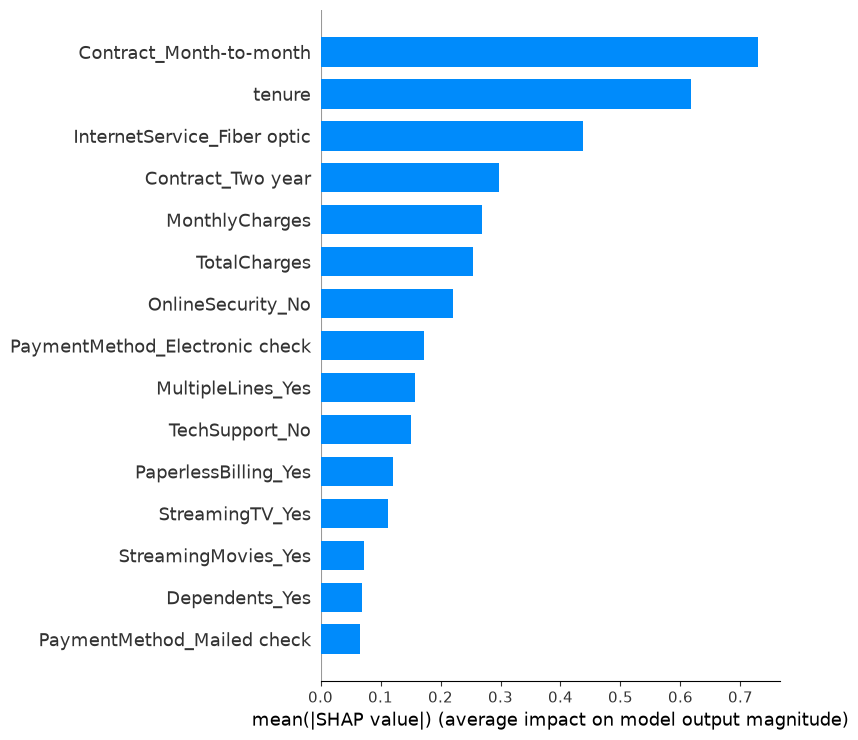

In [31]:
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15)

#SHAP Feature relevance

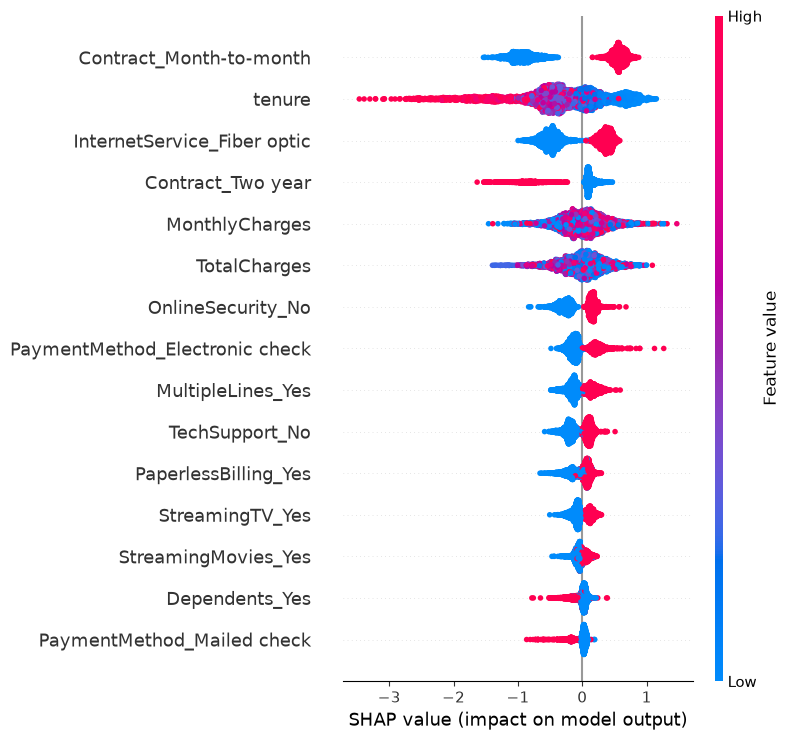

In [32]:
shap.summary_plot(shap_values, X_test, max_display=15)

#Prescriptive analytics - what to do with risk tiers ? Business decisions

In [ ]:
#  SCORE EVERY CUSTOMER 
churn_proba = model.predict_proba(X)[:, 1]

#  BUILD OUTPUT DATAFRAME 
output = df[['customerID', 'IsChurned']].copy()
output['ChurnProbability'] = churn_proba.round(3)

#  RISK BUCKETS 
def risk_tier(p):
    if p >= 0.5:  return 'High'
    if p >= 0.3:  return 'Medium'
    return 'Low'

output['RiskTier'] = output['ChurnProbability'].apply(risk_tier)

# 4. MERGE IN CONTEXT COLUMNS - drop ischurned
temp = df[['customerID', 'Contract', 'PaymentMethod', 'InternetService',
           'OnlineSecurity', 'TechSupport', 'tenure', 'MonthlyCharges']]
output = output.merge(temp, on='customerID', how='left')

# = RETENTION RECOMMENDATIONS 
def recommend(row):
    if row['IsChurned'] == 1:
        return "Already churned — win-back campaign"

    actions = []

    if row['Contract'] == 'Month-to-month':
        actions.append("Offer 1-year contract discount (10–15%)")

    if row['PaymentMethod'] == 'Electronic check':
        actions.append("Incentivize auto-pay migration (£5 credit)")

    if row['InternetService'] == 'Fiber optic' and row['OnlineSecurity'] == 'No':
        actions.append("Bundle OnlineSecurity free for 3 months")

    if row['TechSupport'] == 'No' and row['InternetService'] != 'No':
        actions.append("Offer complimentary TechSupport trial")

    if row['tenure'] <= 12:
        actions.append("Assign to onboarding success outreach")

    if row['MonthlyCharges'] > 80:
        actions.append("VIP retention call from account manager")

    return " | ".join(actions) if actions else "Standard engagement — quarterly check-in"

output['RecommendedActions'] = output.apply(recommend, axis=1)

#  Check Output
output = output.sort_values('ChurnProbability', ascending=False).reset_index(drop=True)

print(f"Total customers scored: {len(output)}")
print(f"\nRisk tier distribution:")
print(output['RiskTier'].value_counts())
print(f"\nTop 10 highest-risk customers:")
output.head(10)

Total customers scored: 20805

Risk tier distribution:
RiskTier
Low       13315
High       4613
Medium     2877
Name: count, dtype: int64

Top 10 highest-risk customers:


,customerID,IsChurned,ChurnProbability,RiskTier,Contract,PaymentMethod,InternetService,OnlineSecurity,TechSupport,tenure,MonthlyCharges,RecommendedActions
0,EMB-0008364,1,0.986,High,Month-to-month,Bank transfer (automatic),Fiber optic,No,No,1,101.00,Already churned — win-back campaign
1,EMB-0002711,1,0.984,High,Month-to-month,Electronic check,Fiber optic,No,No,1,98.32,Already churned — win-back campaign
2,EMB-0017062,1,0.981,High,Month-to-month,Bank transfer (automatic),Fiber optic,No,No,3,101.55,Already churned — win-back campaign
3,EMB-0017581,1,0.977,High,Month-to-month,Electronic check,Fiber optic,No,No,7,109.64,Already churned — win-back campaign
4,EMB-0005910,1,0.975,High,Month-to-month,Electronic check,Fiber optic,No,No,1,101.45,Already churned — win-back campaign
5,EMB-0001395,1,0.975,High,Month-to-month,Bank transfer (automatic),Fiber optic,No,No,3,84.75,Already churned — win-back campaign
6,EMB-0009342,1,0.973,High,Month-to-month,Bank transfer (automatic),Fiber optic,No,No,1,79.19,Already churned — win-back campaign
7,EMB-0003567,1,0.972,High,Month-to-month,Bank transfer (automatic),Fiber optic,No,No,2,94.20,Already churned — win-back campaign
8,EMB-0017282,1,0.972,High,Month-to-month,Electronic check,Fiber optic,No,No,1,100.35,Already churned — win-back campaign
9,EMB-0002502,1,0.970,High,Month-to-month,Electronic check,Fiber optic,No,No,3,99.38,Already churned — win-back campaign


#Save the new outputted excel sheet

In [35]:
output.to_excel(
    r"C:\Users\guest1\OneDrive\Desktop\data analytics portfolio projects\Telecom Churn Analysis\Ember_Churn_Scored.xlsx",
    index=False
)
print("Saved.")

Saved.


#Save thee model File 

In [36]:
import joblib
joblib.dump(model, r"C:\Users\guest1\OneDrive\Desktop\data analytics portfolio projects\Telecom Churn Analysis\ember_churn_xgb.pkl")

['C:\\Users\\guest1\\OneDrive\\Desktop\\data analytics portfolio projects\\Telecom Churn Analysis\\ember_churn_xgb.pkl']